In [1]:
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [38]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import  silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage 
from scipy.cluster.hierarchy import dendrogram
from yellowbrick.cluster import SilhouetteVisualizer

In [5]:
import datetime

In [6]:
df = pd.read_csv('/Users/alex/Downloads/Desktop/Github/Energy_Utilities_Github_Project/Data/energy_utilities_sim.csv')

In [7]:
df

,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,age,marital_status,educational_level,prefecture,average_monthly_visits,average_web_monthly_visits,average_mobile_monthly_visits
0,1,7.797533,-33.932899,2015-05-14,136.200805,40-55,Married,Master’s degree,Neon-Attika,0.865182,0.538854,0.330131
1,2,25.068224,-3.213220,2015-06-02,97.656313,30-39,Married,Bachelor’s degree,Corinthus Crossroads,4.154858,0.697384,3.491964
2,3,7.875073,16.366928,2015-06-29,133.072322,40-55,Married,Master’s degree,Neon-Attika,2.819235,2.394294,0.560970
3,4,12.309787,-2.479825,2015-03-19,88.884085,40-55,Married,Master’s degree,Neon-Attika,0.852767,0.569274,0.238127
4,5,8.888037,14.005530,2014-08-22,64.459468,30-39,Married,Bachelor’s degree,Evoa Conglomerate,11.056524,3.527665,7.131606
...,...,...,...,...,...,...,...,...,...,...,...,...
1248,1249,36.049991,7.913366,2017-01-05,101.345573,30-39,Married,Master’s degree,Chanion Underhive,33.277992,2.605684,30.750945
1249,1250,12.912167,0.000000,2017-01-11,87.722475,40-55,Married,"High school graduate, diploma or the equivalent",Evrax,7.630204,2.578579,4.768062
1250,1251,42.633626,12.018915,2017-01-11,81.664547,40-55,Married,Bachelor’s degree,Rethyx-Pterax,13.177438,1.446155,11.965140
1251,1252,49.460804,5.011639,2017-01-12,120.466909,30-39,Married,"High school graduate, diploma or the equivalent",Kavallon,39.063468,4.521204,36.102688


In [8]:
df.columns

Index(['user_id', 'average_daily_consumption', 'average_days_to_bill_payment',
       'customer_since', 'area', 'age', 'marital_status', 'educational_level',
       'prefecture', 'average_monthly_visits', 'average_web_monthly_visits',
       'average_mobile_monthly_visits'],
      dtype='object')

In [9]:
cols_to_drop = ['prefecture', 'average_monthly_visits']

In [10]:
df_dr = df.copy().drop(columns=cols_to_drop)

In [11]:
area_mask = df_dr[df_dr['area']==0]

In [12]:
area_mask.index

Index([14, 91, 387, 459, 573, 663, 754, 776, 889, 980], dtype='int64')

In [13]:
df_new = df_dr.copy().drop(index=area_mask.index)

In [14]:
df_new.head()

,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,age,marital_status,educational_level,average_web_monthly_visits,average_mobile_monthly_visits
0,1,7.797533,-33.932899,2015-05-14,136.200805,40-55,Married,Master’s degree,0.538854,0.330131
1,2,25.068224,-3.213220,2015-06-02,97.656313,30-39,Married,Bachelor’s degree,0.697384,3.491964
2,3,7.875073,16.366928,2015-06-29,133.072322,40-55,Married,Master’s degree,2.394294,0.560970
3,4,12.309787,-2.479825,2015-03-19,88.884085,40-55,Married,Master’s degree,0.569274,0.238127
4,5,8.888037,14.005530,2014-08-22,64.459468,30-39,Married,Bachelor’s degree,3.527665,7.131606


In [15]:
df_new['days_since'] = (pd.Timestamp.today() - pd.to_datetime(df_new['customer_since'])).dt.days

In [16]:
df_new['days_since']

0       4153
1       4134
2       4107
3       4209
4       4418
        ... 
1248    3551
1249    3545
1250    3545
1251    3544
1252    3544
Name: days_since, Length: 1243, dtype: int64

In [17]:
df_new['area'] = df_new['area'].round(1)

In [18]:
print(df_new['age'].value_counts())

age
30-39            509
40-55            504
19-29            130
56-67             78
68+               20
18 or younger      2
Name: count, dtype: int64


In [19]:
df_new['age'] = df_new['age'].replace('18 or younger', '19-29')

In [20]:
df_new['age'].value_counts()

age
30-39    509
40-55    504
19-29    132
56-67     78
68+       20
Name: count, dtype: int64

In [21]:
df_new['marital_status'].value_counts()

marital_status
Married     906
Single      273
Divorced     48
Widowed      16
Name: count, dtype: int64

In [22]:
df_new['marital_status'] = df_new['marital_status'].replace('Widowed', 'Divorced')

In [23]:
df_new['educational_level'].value_counts()

educational_level
Bachelor’s degree                                  511
High school graduate, diploma or the equivalent    437
Master’s degree                                    238
Doctorate degree                                    29
No degree                                           28
Name: count, dtype: int64

In [24]:
# Ordinal encoding — educational_level (natural order 0..4)
# NOTE: the apostrophe in "Bachelor’s" / "Master’s" is a curly one (’), not (')
edu_order = {
    "No degree": 0,
    "High school graduate, diploma or the equivalent": 1,
    "Bachelor’s degree": 2,
    "Master’s degree": 3,
    "Doctorate degree": 4,
}
df_new["education_level_ord"] = df_new["educational_level"].map(edu_order)

# Stop with a clear message if any value was not found in the dictionary
missing = df_new.loc[df_new["education_level_ord"].isna(), "educational_level"].unique()
assert len(missing) == 0, f"Unmapped education values: {missing}"

df_new["education_level_ord"] = df_new["education_level_ord"].astype(int)
df_new.groupby("education_level_ord")["educational_level"].agg(["first", "count"])

,first,count
education_level_ord,,
0,No degree,28
1,"High school graduate, diploma or the equivalent",437
2,Bachelor’s degree,511
3,Master’s degree,238
4,Doctorate degree,29


In [29]:
# Ordinal encoding — age (natural order 0..4)
# "18 or younger" was merged into "19-29" above, so the youngest group is "19-29"
age_order = {
    "19-29": 0,
    "30-39": 1,
    "40-55": 2,
    "56-67": 3,
    "68+": 4,
}
df_new["age_ord"] = df_new["age"].map(age_order)

missing = df_new.loc[df_new["age_ord"].isna(), "age"].unique()
assert len(missing) == 0, f"Unmapped age values: {missing}"

df_new["age_ord"] = df_new["age_ord"].astype(int)
df_new.groupby("age_ord")["age"].agg(["first", "count"])

,first,count
age_ord,,
0,19-29,132
1,30-39,509
2,40-55,504
3,56-67,78
4,68+,20


In [26]:
# One-hot encoding — marital_status (no natural order)
marital_dummies = pd.get_dummies(df_new["marital_status"], prefix="marital", dtype=int)
marital_dummies.columns = marital_dummies.columns.str.lower()
marital_dummies.sum()

marital_divorced     64
marital_married     906
marital_single      273
dtype: int64

In [27]:
# Final dataset: drop the original text columns, keep the encoded ones
df_encoded = pd.concat(
    [df_new.drop(columns=["educational_level", "age", "marital_status"]), marital_dummies],
    axis=1,
)
print(df_encoded.shape)
df_encoded.head()

(1243, 13)


,user_id,average_daily_consumption,average_days_to_bill_payment,customer_since,area,average_web_monthly_visits,average_mobile_monthly_visits,days_since,education_level_ord,age_ord,marital_divorced,marital_married,marital_single
0,1,7.797533,-33.932899,2015-05-14,136.2,0.538854,0.330131,4153,3,2,0,1,0
1,2,25.068224,-3.213220,2015-06-02,97.7,0.697384,3.491964,4134,2,1,0,1,0
2,3,7.875073,16.366928,2015-06-29,133.1,2.394294,0.560970,4107,3,2,0,1,0
3,4,12.309787,-2.479825,2015-03-19,88.9,0.569274,0.238127,4209,3,2,0,1,0
4,5,8.888037,14.005530,2014-08-22,64.5,3.527665,7.131606,4418,2,1,0,1,0


In [35]:
target_cols = ["area", "average_web_monthly_visits", "average_mobile_monthly_visits",
               "days_since", "average_daily_consumption", "average_days_to_bill_payment"]

df_target = df_encoded[target_cols].copy()
df_target.shape 

(1243, 6)

<Axes: >

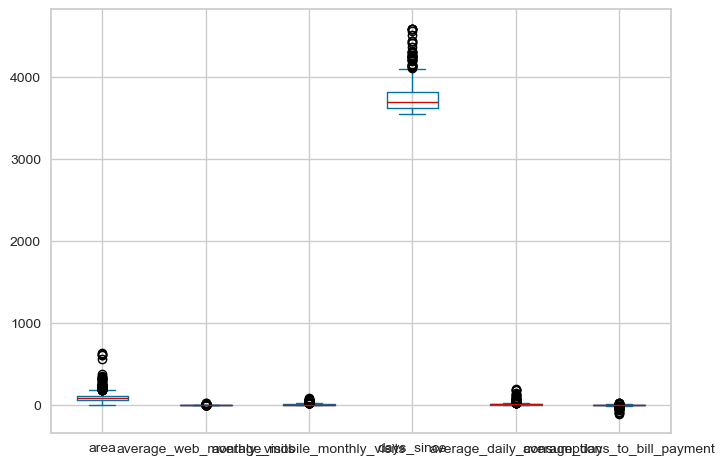

In [36]:
df_target.plot(kind='box')

In [59]:
# %%
# Log transform + clipping before scaling
# area, consumption and visits are heavily right-skewed: a few customers with
# huge values would otherwise get a cluster of their own.
# log1p(x) = log(1 + x), which also works for zeros.
log_cols = ["area", "average_daily_consumption",
            "average_web_monthly_visits", "average_mobile_monthly_visits"]
 
df_target_log = df_target.copy()
df_target_log[log_cols] = np.log1p(df_target_log[log_cols])

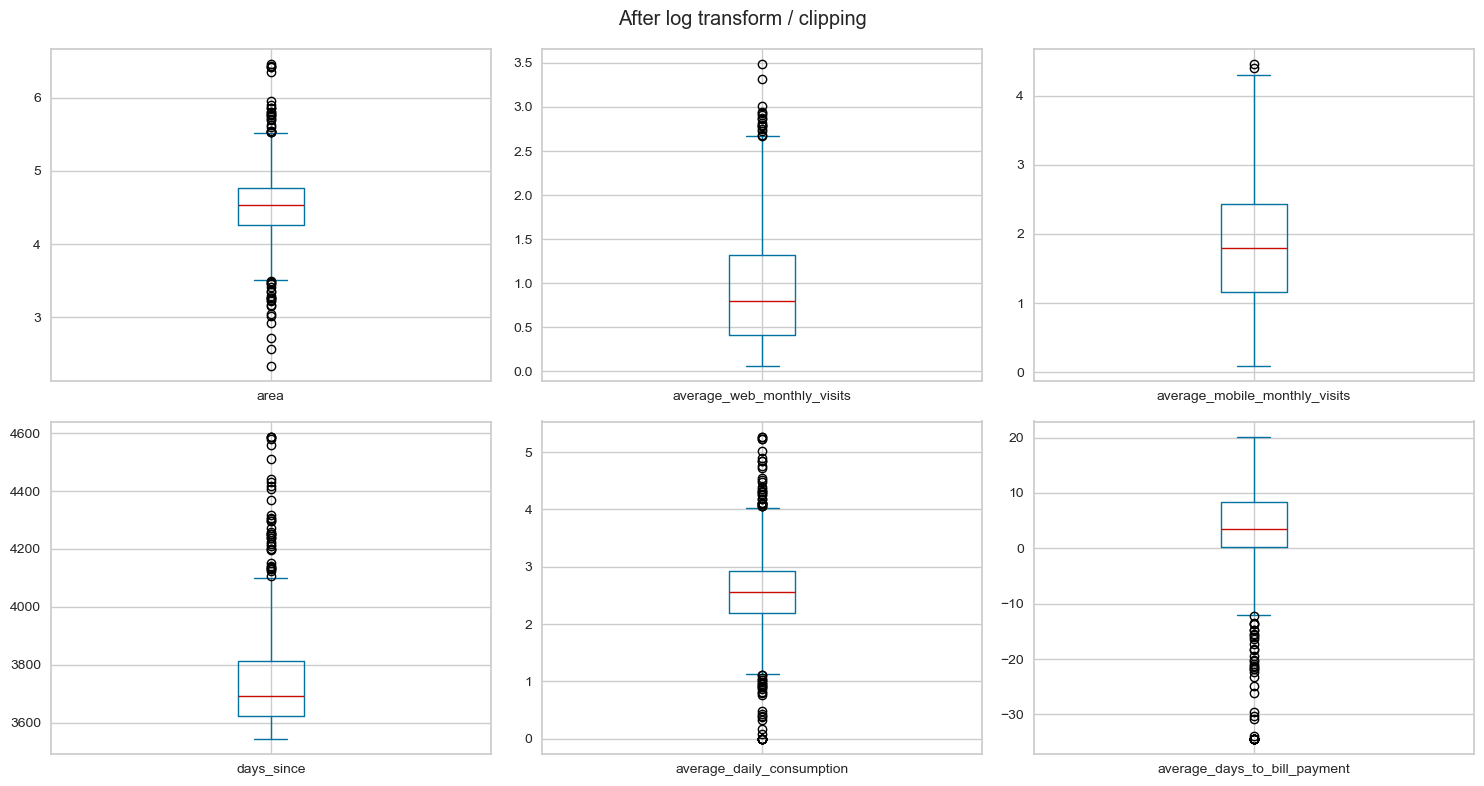

In [60]:
# Days to bill payment can be negative, so no log: clip the extreme 1% on each side instead
lo, hi = df_target_log["average_days_to_bill_payment"].quantile([0.01, 0.99])
df_target_log["average_days_to_bill_payment"] = df_target_log["average_days_to_bill_payment"].clip(lo, hi)
 
# Skewness before vs after (values close to 0 = symmetric)
pd.DataFrame({"before": df_target.skew(), "after": df_target_log.skew()}).round(2)
 
 
# %%
# Boxplots after the transform, each variable on its own axis
df_target_log.plot(kind="box", subplots=True, layout=(2, 3), figsize=(15, 8), sharey=False)
plt.suptitle("After log transform / clipping")
plt.tight_layout()
plt.show()

In [61]:
ss = StandardScaler()
ss.fit(df_target)

StandardScaler()

In [62]:
X = ss.transform(df_target)
X

array([[ 0.64784696, -0.58332825, -0.78174388,  2.68735051, -0.47463206,
        -3.80480605],
       [-0.04058475, -0.53135797, -0.4719944 ,  2.56577151,  0.54229883,
        -0.69173526],
       [ 0.59241479,  0.02493329, -0.75912968,  2.39300135, -0.47006637,
         1.29247773],
       ...,
       [-0.32668624, -0.28589118,  0.35808161, -1.20317756,  1.57658278,
         0.85185881],
       [ 0.36710987,  0.72218964,  2.7227203 , -1.20957645,  1.97857993,
         0.1417555 ],
       [ 0.22048286,  0.81489847, -0.23369933, -1.20957645,  0.10827168,
         0.99313244]])

In [63]:
model_kmeans = KMeans(n_clusters=2, random_state=0).fit(X)

In [64]:
model_kmeans.labels_

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

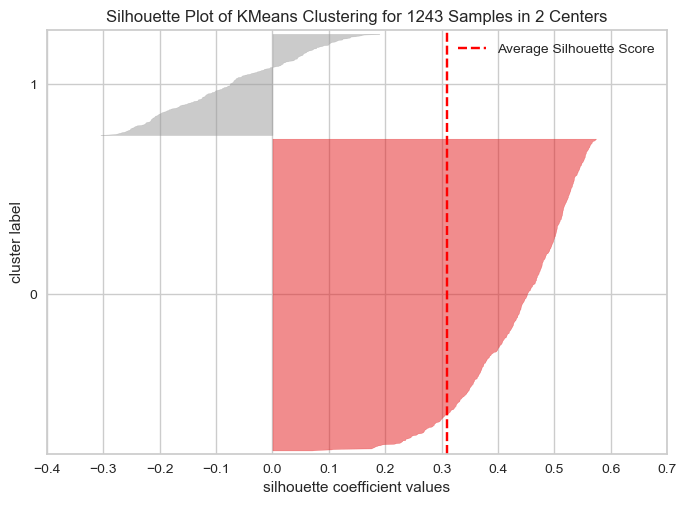

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 1243 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [65]:
# Silhouette Score

vizualizer = SilhouetteVisualizer(model_kmeans,color='yellowbrick')
vizualizer.fit(X)
vizualizer.poof()

In [66]:
len(X)

1243

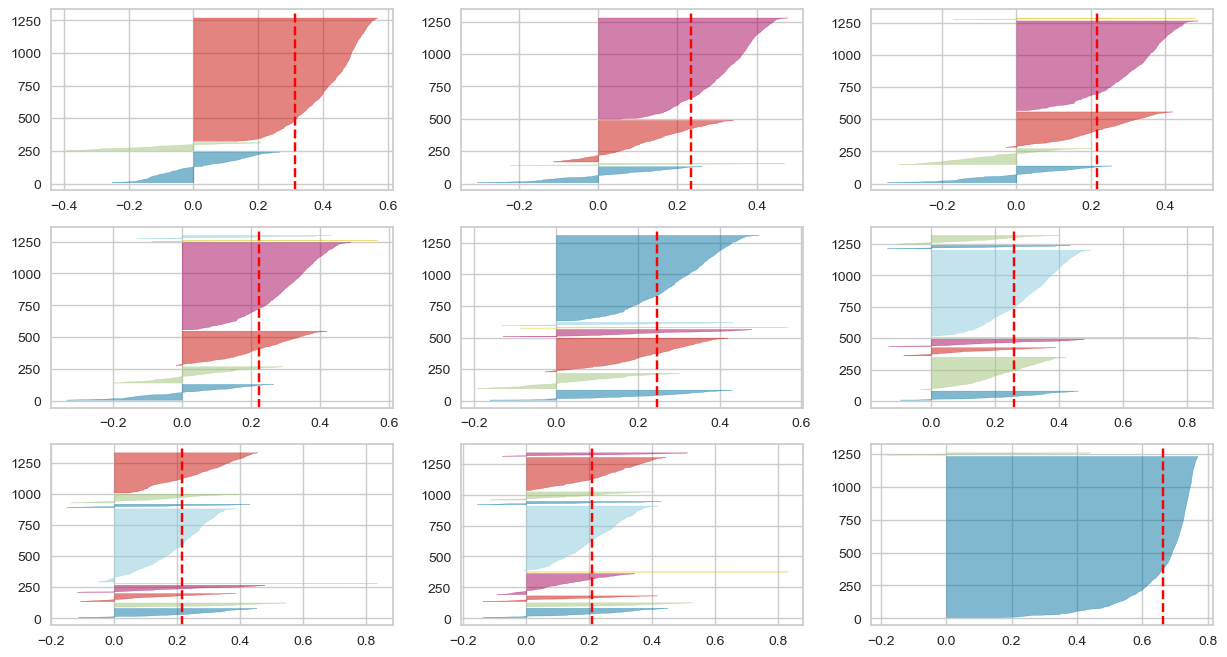

In [68]:
fig, ax = plt.subplots(3,3,figsize=(15,8))
 
 
for i in [2,3,4,5,6,7,8,9,10]:
 
    km = KMeans(n_clusters=i,max_iter=100,random_state=42)
    q,mod = divmod(i,3)
    visuaziler = SilhouetteVisualizer(km,colors="yellowbrick", ax = ax[q-1][mod])
    visuaziler.fit(X)

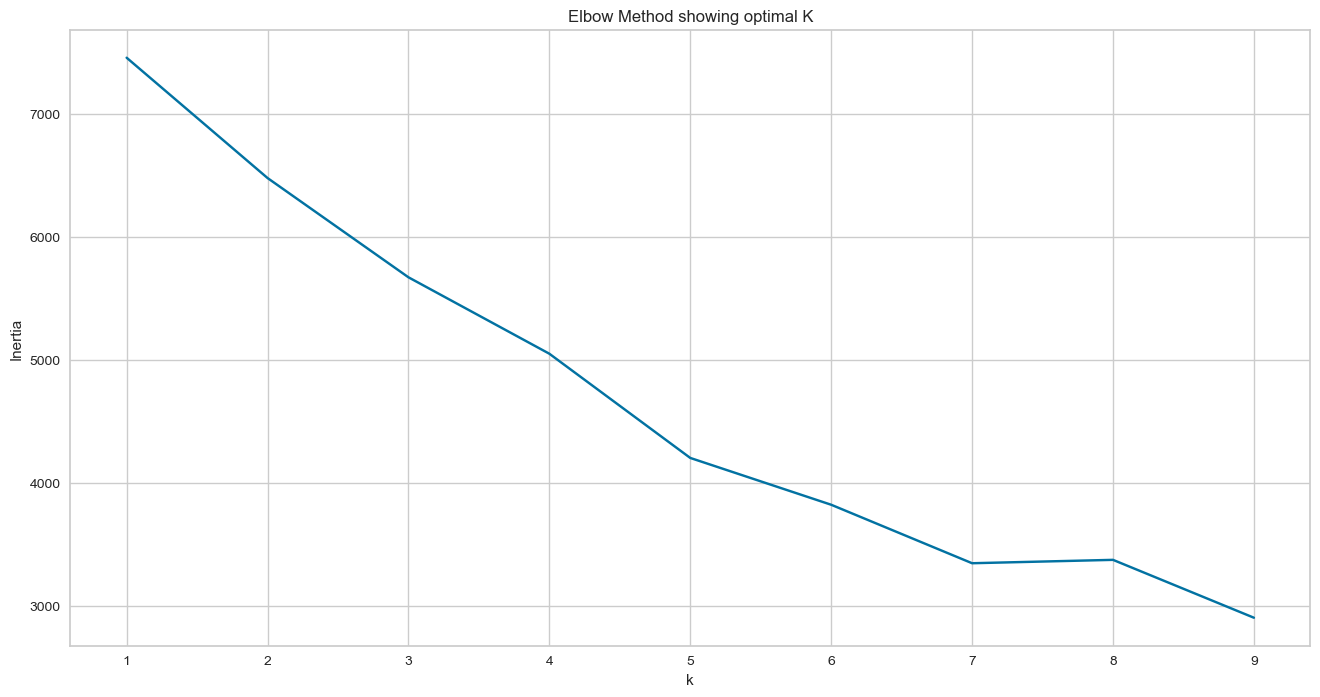

In [69]:
# Elbow Method

inertia = []

K = range(1,10)

for k in K:

    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X)
    inertia.append(kmeanModel.inertia_)

plt.figure(figsize=(16,8))
plt.plot(K,inertia,'bx-')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method showing optimal K")
plt.show()

<Axes: >

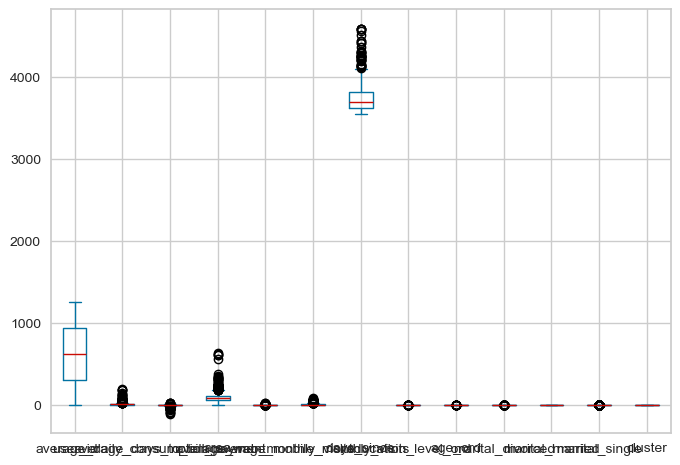

In [70]:
df_encoded.plot(kind='box')

In [71]:
ord_cols = ["education_level_ord", "age_ord"]
dummy_cols = ["marital_divorced", "marital_married", "marital_single"]

In [72]:
ss_ord = StandardScaler()
X_ord = ss_ord.fit_transform(df_encoded[ord_cols])

In [76]:
X_full = pd.concat(
    [
        pd.DataFrame(X, columns=target_cols, index=df_encoded.index),
        pd.DataFrame(X_ord, columns=ord_cols, index=df_encoded.index),
        df_encoded[dummy_cols],
    ],
    axis=1,
)
extra_cols = ord_cols + dummy_cols
 
print(X_full.shape)


(1243, 11)


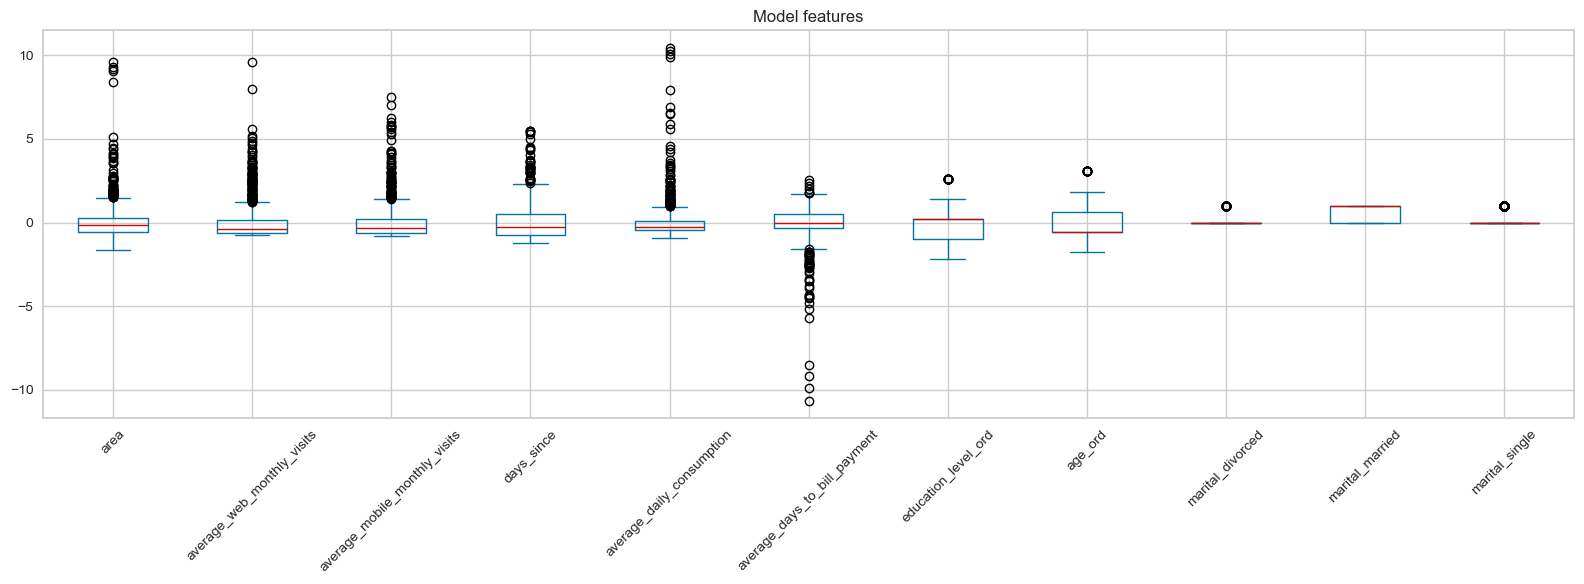

In [77]:
X_full.plot(kind="box", figsize=(16, 6), rot=45)
plt.title("Model features")
plt.tight_layout()
plt.show()

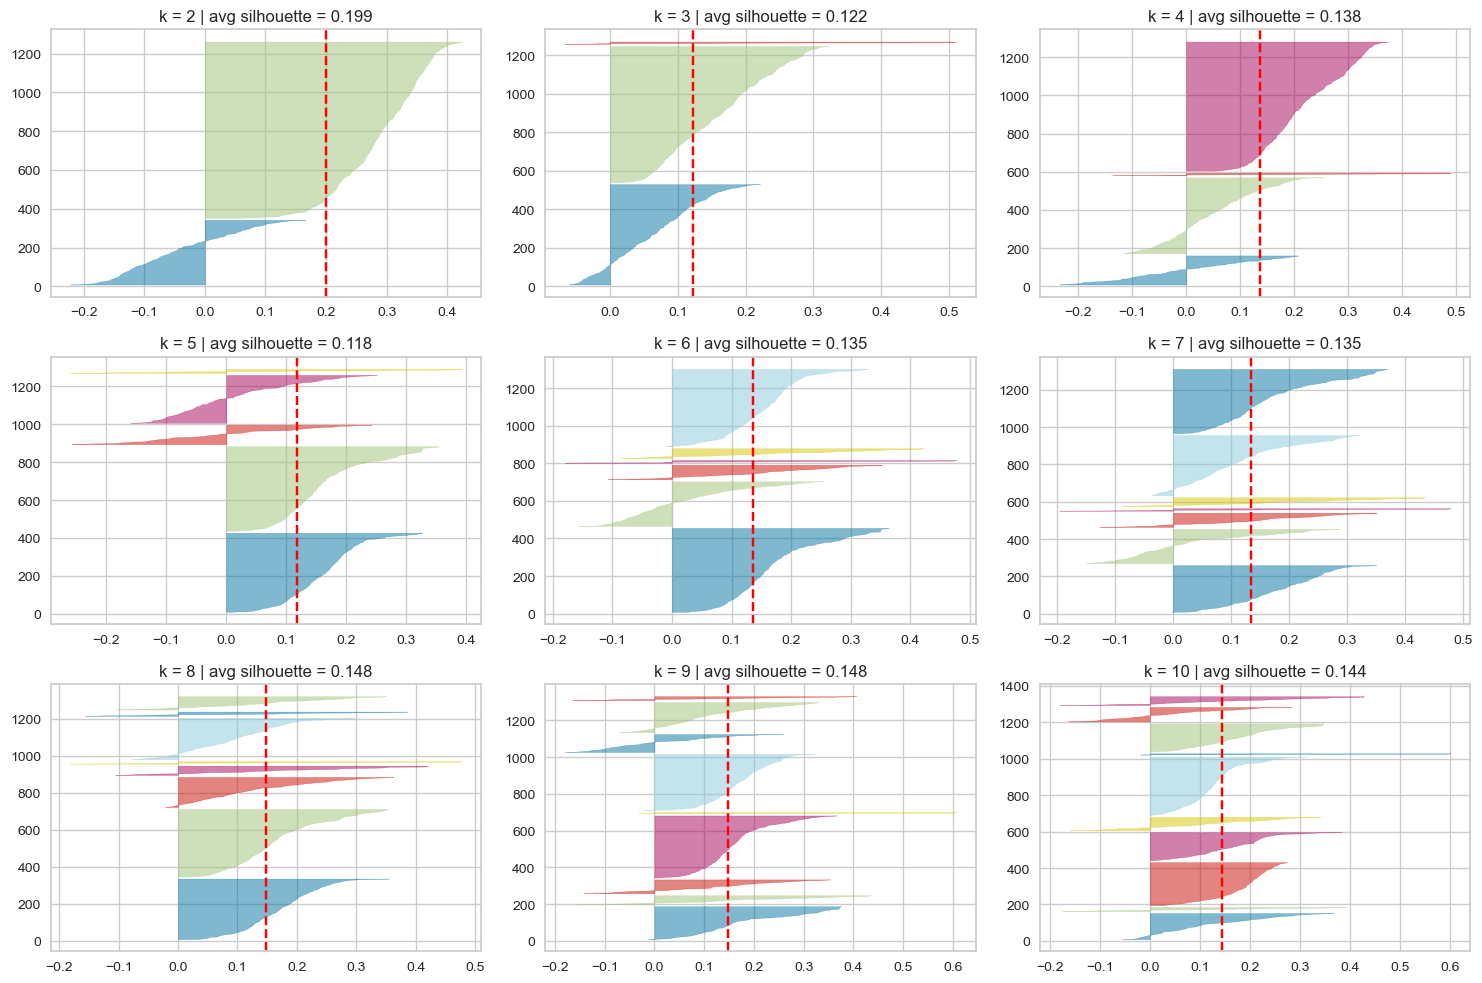

In [78]:
#silhouette score for k=2,10
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
 
for idx, k in enumerate(range(2, 11)):
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    viz = SilhouetteVisualizer(km, colors="yellowbrick", ax=ax[idx // 3][idx % 3])
    viz.fit(X_full)
    ax[idx // 3][idx % 3].set_title(f"k = {k} | avg silhouette = {viz.silhouette_score_:.3f}")
 
plt.tight_layout()
plt.show()

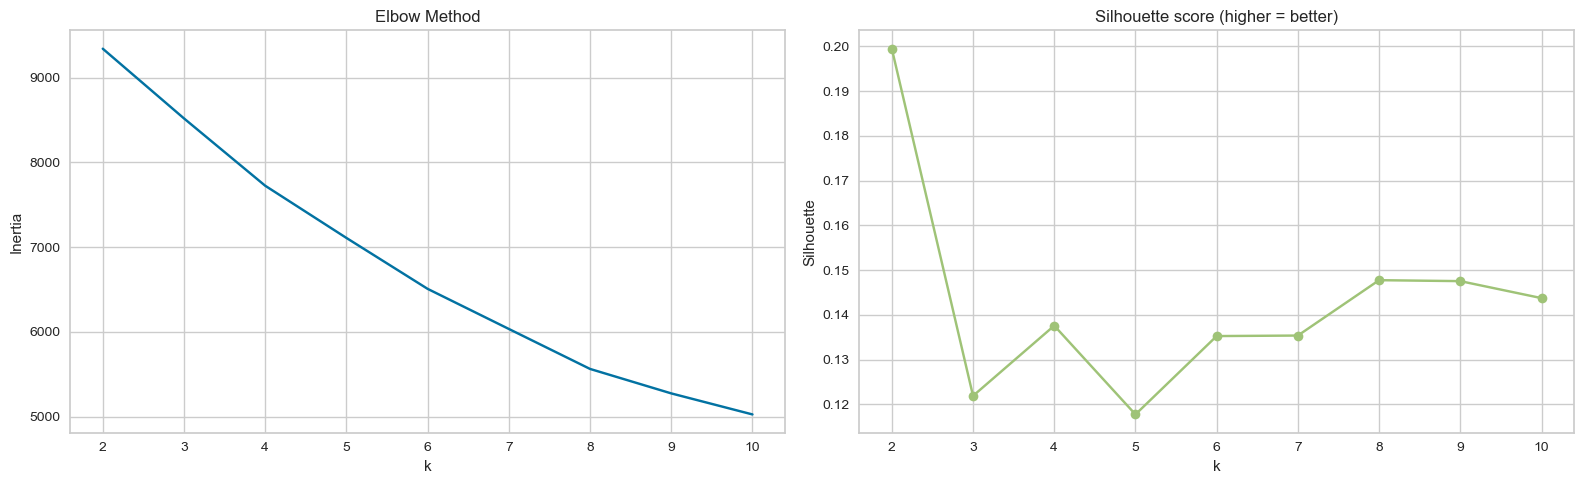

In [79]:
# Elbow method + silhouette score side by side
K = range(2, 11)
inertia, sil = [], []
 
for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_full)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_full, km.labels_))
 
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(K, inertia, "bx-"); ax[0].set(xlabel="k", ylabel="Inertia", title="Elbow Method")
ax[1].plot(K, sil, "go-");     ax[1].set(xlabel="k", ylabel="Silhouette", title="Silhouette score (higher = better)")
plt.tight_layout()
plt.show()
 
pd.DataFrame({"k": list(K), "inertia": inertia, "silhouette": sil}).round(3)
plt.show()

In [80]:
#we take optimal k=4

# After the log transform, silhouette is flat (~0.11-0.12) for every k, so the
# choice is based on stability and interpretability:
#   k=3 -> stable but too coarse
#   k=4 -> stable (same clusters with different random seeds), balanced sizes,
#          4 clearly different customer types
#   k=5+ -> clusters change a lot between runs (unstable)
k_final = 4
 
model_full = KMeans(n_clusters=k_final, n_init=10, random_state=42).fit(X_full)
df_encoded["cluster"] = model_full.labels_
 
df_encoded["cluster"].value_counts().sort_index()
 
 
# %%
# Cluster profiles in ORIGINAL units (easier to interpret than scaled values)
profile_cols = target_cols + extra_cols
 
profile = df_encoded.groupby("cluster")[profile_cols].mean().round(2)
profile["n_customers"] = df_encoded["cluster"].value_counts().sort_index()
profile


,area,average_web_monthly_visits,average_mobile_monthly_visits,days_since,average_daily_consumption,average_days_to_bill_payment,education_level_ord,age_ord,marital_divorced,marital_married,marital_single,n_customers
cluster,,,,,,,,,,,,
0,99.10,7.80,22.74,3656.39,18.36,6.11,1.86,1.65,0.03,0.82,0.15,153
1,113.96,1.45,4.25,3826.03,14.91,1.08,2.59,1.54,0.05,0.77,0.18,399
2,384.12,2.48,5.29,3745.71,121.26,6.99,2.50,1.71,0.00,0.86,0.14,14
3,86.04,1.59,7.51,3695.28,13.67,4.47,1.38,1.39,0.06,0.68,0.26,677


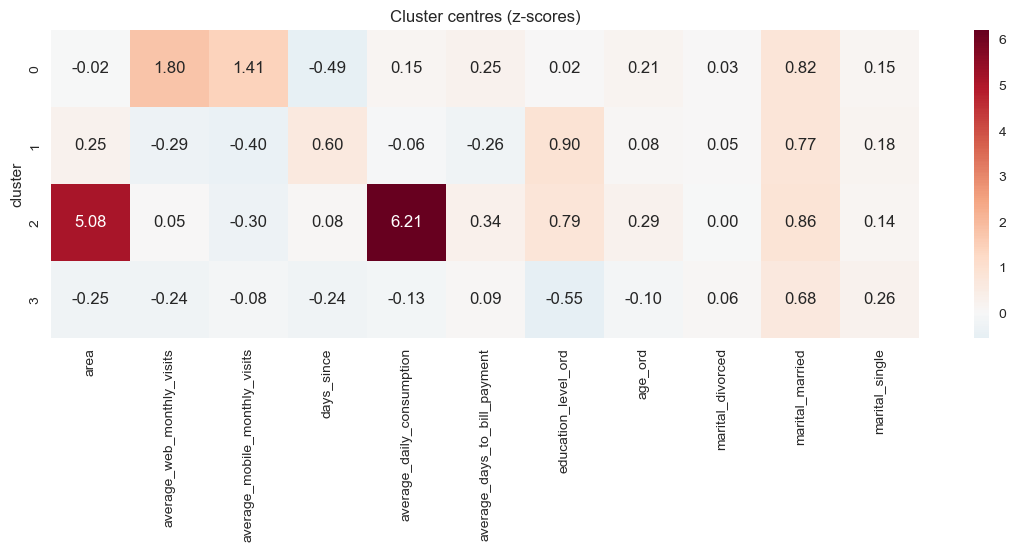

In [84]:
# Heatmap of cluster centres in scaled units:
# red = above the average customer, blue = below

centers = pd.DataFrame(model_full.cluster_centers_, columns=X_full.columns)
 
plt.figure(figsize=(14, 4))
sns.heatmap(centers, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster centres (z-scores)")
plt.ylabel("cluster")
plt.show()

In [85]:
# Stability check: run K-Means with different random seeds and compare the results.
# Adjusted Rand Index (ARI) = 1 means identical clusters, 0 means random.
from sklearn.metrics import adjusted_rand_score
 
for k in [3, 4, 5]:
    runs = [KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X_full) for seed in range(6)]
    ari = np.mean([adjusted_rand_score(runs[0], r) for r in runs[1:]])
    print(f"k={k}: mean ARI across seeds = {ari:.3f}")
 

k=3: mean ARI across seeds = 0.301
k=4: mean ARI across seeds = 0.656
k=5: mean ARI across seeds = 0.691


In [86]:
# Segment names — based on the cluster profiles and heatmap above.
# WARNING: cluster IDs can come out in a different order on another
# scikit-learn version. Check the heatmap and fix the mapping if needed:
#   high days_since + low mobile             -> Loyal offline
#   high web/mobile + high consumption       -> Digital heavy users
#   low days_to_bill_payment + low education -> Payment risk
#   young, single, small home                -> Young starters
segment_names = {
    0: "Loyal offline",
    1: "Digital heavy users",
    2: "Payment risk",
    3: "Young starters",
}
df_encoded["segment"] = df_encoded["cluster"].map(segment_names)
df_encoded["segment"].value_counts()

segment
Young starters         677
Digital heavy users    399
Loyal offline          153
Payment risk            14
Name: count, dtype: int64

In [87]:
# Share of customers with a negative average days to bill payment, per segment
(df_encoded["average_days_to_bill_payment"] < 0).groupby(df_encoded["segment"]).mean().mul(100).round(0)

segment
Digital heavy users    24.0
Loyal offline          12.0
Payment risk            0.0
Young starters         18.0
Name: average_days_to_bill_payment, dtype: float64

In [88]:
# Business question: how can the company reduce late payments and increase the
# use of digital channels, with targeted actions per segment?
#
# Steps:
#   1. Size the problem per segment -> where to focus first
#   2. Build target lists of customers for each action
#   3. Assign new customers to a segment automatically
#   4. Set up an A/B test to measure whether the actions work
 
 
# %%
# 1. Size the problem per segment
# late payer   = average days to bill payment < 0 (confirm the meaning of the sign!)
# low digital  = bottom 25% of total web + mobile visits
df_encoded["late_payer"] = df_encoded["average_days_to_bill_payment"] < 0
df_encoded["digital_visits"] = (df_encoded["average_web_monthly_visits"]
                                + df_encoded["average_mobile_monthly_visits"])
low_digital_threshold = df_encoded["digital_visits"].quantile(0.25)
df_encoded["low_digital"] = df_encoded["digital_visits"] < low_digital_threshold
 
problem_size = df_encoded.groupby("segment").agg(
    customers=("user_id", "size"),
    late_payers=("late_payer", "sum"),
    late_rate=("late_payer", "mean"),
    low_digital=("low_digital", "sum"),
    low_digital_rate=("low_digital", "mean"),
    median_consumption=("average_daily_consumption", "median"),
)

In [89]:
# Which share of ALL late payers / low-digital customers sits in each segment
problem_size["share_of_all_late"] = problem_size["late_payers"] / problem_size["late_payers"].sum()
problem_size["share_of_all_low_digital"] = problem_size["low_digital"] / problem_size["low_digital"].sum()
problem_size.round(2)

,customers,late_payers,late_rate,low_digital,low_digital_rate,median_consumption,share_of_all_late,share_of_all_low_digital
segment,,,,,,,,
Digital heavy users,399,94,0.24,170,0.43,12.31,0.40,0.55
Loyal offline,153,18,0.12,0,0.00,12.77,0.08,0.00
Payment risk,14,0,0.00,6,0.43,126.67,0.00,0.02
Young starters,677,121,0.18,135,0.20,11.26,0.52,0.43


# Visual: where the late payers and the low-digital customers are


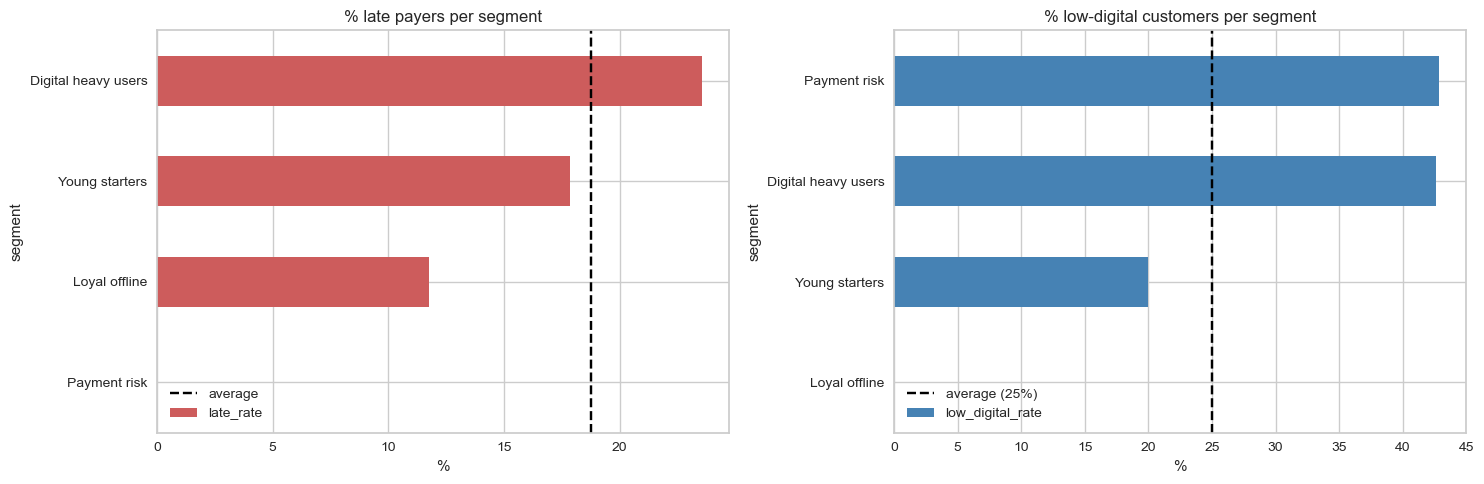

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
problem_size["late_rate"].mul(100).sort_values().plot(kind="barh", ax=ax[0], color="indianred")
ax[0].axvline(df_encoded["late_payer"].mean() * 100, color="black", ls="--", label="average")
ax[0].set(title="% late payers per segment", xlabel="%"); ax[0].legend()
 
problem_size["low_digital_rate"].mul(100).sort_values().plot(kind="barh", ax=ax[1], color="steelblue")
ax[1].axvline(25, color="black", ls="--", label="average (25%)")
ax[1].set(title="% low-digital customers per segment", xlabel="%"); ax[1].legend()
plt.tight_layout()
plt.show()

In [91]:
 #2. Target lists per action
# Each action targets a specific group of customers. Export them so the
# marketing / collections teams can use them.
actions = {
    # Payment reminders + direct debit incentive: late payers in the risk segment
    "payment_reminders": (df_encoded["segment"] == "Payment risk") & df_encoded["late_payer"],
    # Digital onboarding: low-digital customers in the loyal offline segment
    "digital_onboarding": (df_encoded["segment"] == "Loyal offline") & df_encoded["low_digital"],
    # Energy-saving tips + cross-selling in the app: digital heavy users
    "app_upsell": df_encoded["segment"] == "Digital heavy users",
    # Simple starter plans: young starters
    "starter_plans": df_encoded["segment"] == "Young starters",
}
 
for name, mask in actions.items():
    print(f"{name:20s} {mask.sum():4d} customers")

payment_reminders       0 customers
digital_onboarding      0 customers
app_upsell            399 customers
starter_plans         677 customers
